# Day 2 — AI Model Failure Detection

**Project:** AI Model Failure Detection & Explainability System  
**Objective:** Analyze prediction confidence behaviour and detect conditions under which the model is likely to fail.

This notebook investigates model reliability by studying confidence distributions and constructing a Failure Risk Score.

---

**Author:** Rishikesh Singh  
**Role:** Data Science Student  
**Project Stage:** Failure Behaviour Analysis (Day 2)  
**Tools:** Python, Scikit-learn, Pandas, Matplotlib, Seaborn

## Step 1 — Environment Setup and Model Loading
Load required libraries and the trained baseline model from Day 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

model = joblib.load("../models/baseline_pipeline.pkl")
print("Model loaded successfully")

Model loaded successfully


## Step 2 — Dataset Preparation
Load dataset and reproduce preprocessing used during baseline training.

In [2]:
df = pd.read_csv("../data/dataset.csv")
df = df.drop(columns=['customerID'], errors='ignore')

X = df.drop(columns=['Churn'])
y = df['Churn']

from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include='object').columns
le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

y = LabelEncoder().fit_transform(y)

## Step 3 — Generate Predictions and Identify Failures
Evaluate model predictions and mark incorrect classifications.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred
results["Confidence"] = y_prob

results["Failure"] = results["Actual"] != results["Predicted"]

print("Total failures:", results["Failure"].sum())
results.head()

Total failures: 363


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Confidence,Failure
437,1,0,1,1,72,1,2,1,2,2,...,2,2,1,1,114.05,6196,0,0,0.098673,False
2280,0,1,0,0,8,1,2,1,0,0,...,2,0,1,1,100.15,6340,0,1,0.904565,True
2235,0,0,1,1,41,1,2,0,2,2,...,0,1,1,1,78.35,2796,0,0,0.188510,False
4460,1,0,1,0,18,1,0,1,0,0,...,0,0,0,2,78.20,862,0,1,0.580475,True
3761,0,0,1,0,72,1,2,0,2,2,...,2,2,1,1,82.65,4855,0,0,0.064072,False


## Step 4 — Confidence Behaviour Analysis
Study how prediction confidence differs between correct and failed predictions.

### Histogram.

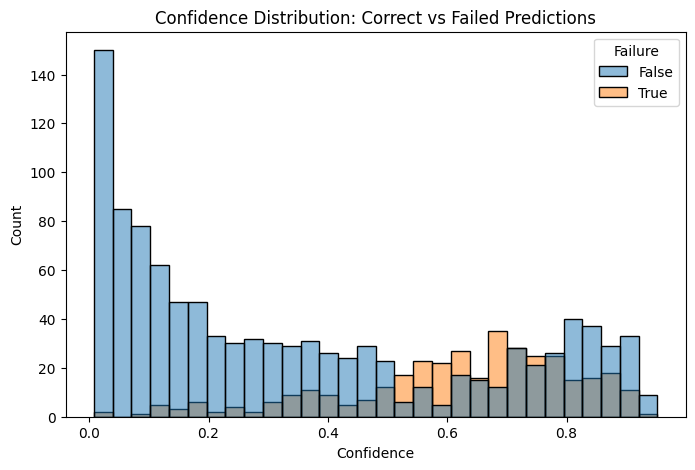

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(data=results, x="Confidence", hue="Failure", bins=30)
plt.title("Confidence Distribution: Correct vs Failed Predictions")
plt.show()

### Confidence Bands.

/var/folders/rt/48gpknks5mlc888bjxc5dfx00000gn/T/ipykernel_1556/2204746475.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rate = results.groupby("confidence_band")["Failure"].mean()


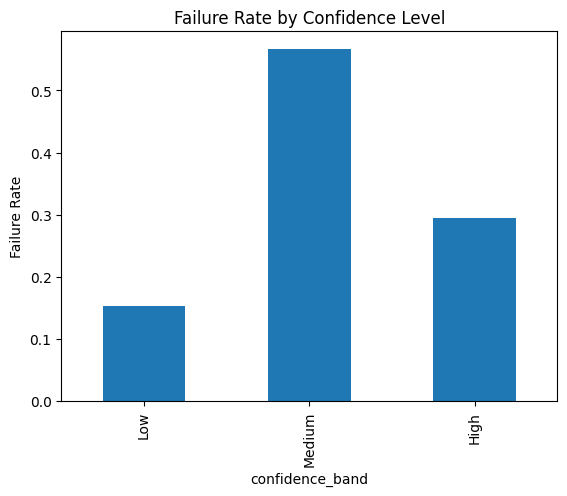

In [5]:
results["confidence_band"] = pd.cut(
    results["Confidence"],
    bins=[0, 0.6, 0.8, 1.0],
    labels=["Low", "Medium", "High"]
)

failure_rate = results.groupby("confidence_band")["Failure"].mean()

failure_rate.plot(kind="bar")
plt.title("Failure Rate by Confidence Level")
plt.ylabel("Failure Rate")
plt.show()

### Average Confidence.

In [6]:
results.groupby("Failure")["Confidence"].mean()

Failure
False    0.345042
True     0.618245
Name: Confidence, dtype: float64

## Observation — Overconfident Failures

Failed predictions show higher average confidence than correct predictions.

This indicates **overconfidence bias**, meaning prediction probability alone is not a reliable indicator of correctness.

Therefore, an additional reliability metric is required.

## Step 5 — Failure Risk Score

A risk score is computed using distance from the decision boundary (0.5).
Predictions closer to the boundary are considered more unstable and therefore riskier.

In [7]:
results["distance_from_boundary"] = abs(results["Confidence"] - 0.5)
results["failure_risk_score"] = 1 - results["distance_from_boundary"]

results[["Confidence", "failure_risk_score"]].head()

,Confidence,failure_risk_score
437,0.098673,0.598673
2280,0.904565,0.595435
2235,0.188510,0.688510
4460,0.580475,0.919525
3761,0.064072,0.564072


### Validation.

In [8]:
results.groupby("Failure")["failure_risk_score"].median()

Failure
False    0.667576
True     0.813784
Name: failure_risk_score, dtype: float64

### Visualization.

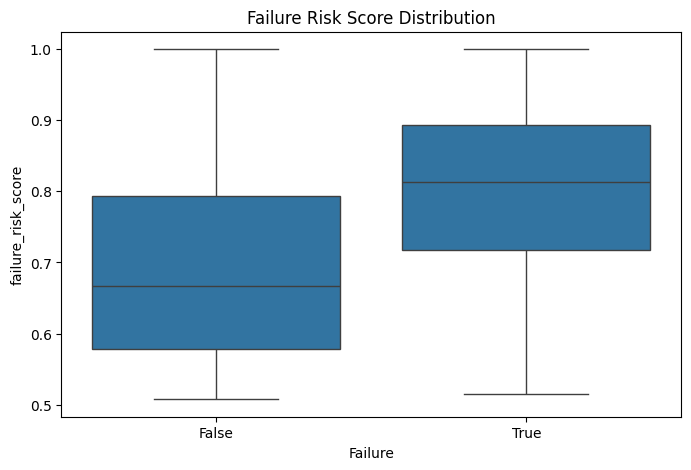

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Failure", y="failure_risk_score", data=results)
plt.title("Failure Risk Score Distribution")
plt.show()

## Day 2 Conclusion — Failure Detection Insight

Analysis revealed that failed predictions have higher confidence on average, demonstrating overconfidence bias in the model.

A Failure Risk Score based on distance from the decision boundary was introduced and validated.

Results show that failed predictions possess higher median risk scores than correct predictions, confirming that failures occur in identifiable uncertainty regions rather than randomly.

This establishes a reliability layer on top of the prediction model and forms the foundation for explainable failure analysis in subsequent stages.